In [1]:
# Importing Libraries :)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data Ingestion
patient_data = pd.read_csv("data.csv")

In [3]:
patient_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<Axes: >

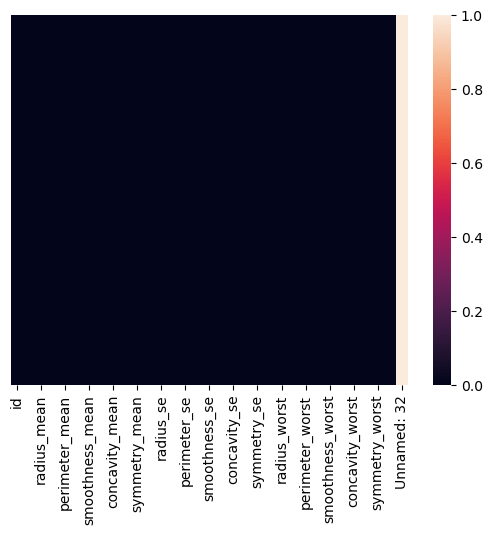

In [4]:
sns.heatmap(patient_data.isnull(), yticklabels=False)

## Data Preparation

In [5]:
# Data Cleaning
patient_data.drop(["Unnamed: 32","id"], axis=1, inplace=True)

In [6]:
# Data Preprocessing
patient_data.diagnosis = [1 if it == "M" else 0 for it in patient_data.diagnosis]

Text(0.5, 1.0, 'Distribution of Diagnosis Counts')

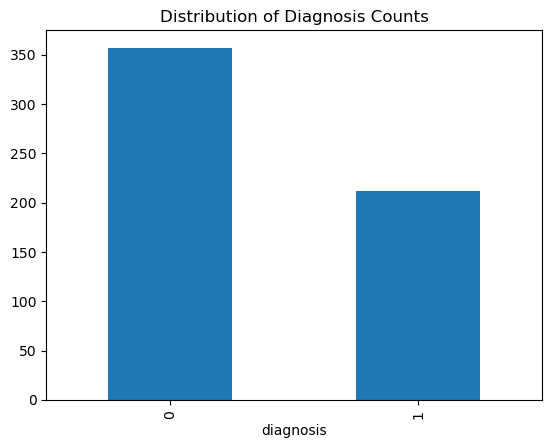

In [7]:
# Turning the target variable into categorical data
patient_data.diagnosis = patient_data.diagnosis.astype('category',copy=False)
patient_data.diagnosis.value_counts().plot(kind="bar")
plt.title("Distribution of Diagnosis Counts")

## Importing & Training the model

In [8]:
# Defining features and Target Variable
y=patient_data.diagnosis
x=patient_data.drop("diagnosis", axis=1)

In [9]:
# Normalization of data
from sklearn.preprocessing import StandardScaler

# Create an instance scaler object
scaler = StandardScaler()
#Fit the scaler to the data and transform the data
x_scaled = scaler.fit_transform(x)

In [10]:
# Train test split (80/20)
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression

# Creating an instance of Logistic Regression
model = LogisticRegression()
# Training the model
model.fit(x_train, y_train)
# Predicting the target variable
y_pred = model.predict(x_test)

## Evaluating the model

In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_pred, y_test)
accuracy = accuracy*100
print(f"Accuracy : {accuracy:.2f}%")

Accuracy : 97.37%


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Text(0.5, 1.0, 'Confusion Matrix')

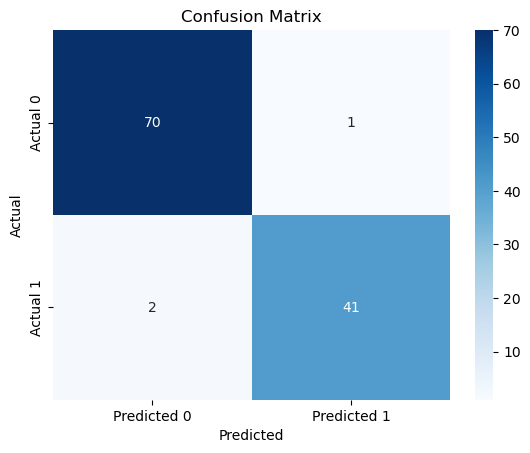

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
